In [ ]:
!pip install pandas numpy scikit-learn tensorflow

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input
from tensorflow.keras.models import Model

luad = pd.read_csv("TCGA-LUAD.star_tpm.tsv", sep="\t")
lusc = pd.read_csv("TCGA-LUSC.star_tpm.tsv", sep="\t")

luad = luad.set_index(luad.columns[0])
lusc = lusc.set_index(lusc.columns[0])

luad = luad.T
lusc = lusc.T

print(luad.shape)
print(lusc.shape)

(589, 60660)
(552, 60660)


In [2]:
LUAD = 0
LUSC = 1
luad['subtype'] = 0
lusc['subtype'] = 1

data = pd.concat([luad, lusc])
data = data.sample(frac=1).reset_index(drop=True)
X = data.drop(columns=['subtype'])
y = data['subtype']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.feature_selection import VarianceThreshold
var_filter = VarianceThreshold(threshold=0)
X_filtered = var_filter.fit_transform(X_scaled)

selector = SelectKBest(score_func=f_classif, k=1000)
X_selected = selector.fit_transform(X_filtered, y)
print("Selected feature shape:", X_selected.shape)

Selected feature shape: (1141, 1000)


In [3]:
severity_score = X_selected.mean(axis=1)
threshold = np.median(severity_score)
severity = []
for s in severity_score:
    if s > threshold:
        severity.append(1)
    else:
        severity.append(0)
severity = np.array(severity)

X_train, X_test, y_train, y_test, sev_train, sev_test = train_test_split(
    X_selected,
    y,
    severity,
    test_size=0.2,
    random_state=42
)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

input_layer = Input(shape=(X_train.shape[1],1))
x = Conv1D(64,3,activation='relu')(input_layer)
x = MaxPooling1D(2)(x)
x = Conv1D(128,3,activation='relu')(x)
x = MaxPooling1D(2)(x)
x = Flatten()(x)
x = Dense(128,activation='relu')(x)
x = Dropout(0.5)(x)
subtype_output = Dense(1,activation='sigmoid',name='subtype')(x)
severity_output = Dense(1,activation='sigmoid',name='severity')(x)
model = Model(inputs=input_layer, outputs=[subtype_output,severity_output])

model.compile(
    optimizer='adam',
    loss={
        'subtype': 'binary_crossentropy',
        'severity': 'binary_crossentropy'
    },
    metrics={
        'subtype': 'accuracy',
        'severity': 'accuracy'
    }
)

history = model.fit(
    X_train,
    {
        'subtype':y_train,
        'severity':sev_train
    },
    validation_data=(
        X_test,
        {
            'subtype':y_test,
            'severity':sev_test
        }
    ),
    epochs=30,
    batch_size=32
)


Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step - loss: 1.2327 - severity_accuracy: 0.7085 - severity_loss: 0.8155 - subtype_accuracy: 0.8008 - subtype_loss: 0.4164 - val_loss: 0.3416 - val_severity_accuracy: 0.9301 - val_severity_loss: 0.1247 - val_subtype_accuracy: 0.9170 - val_subtype_loss: 0.2097
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3678 - severity_accuracy: 0.9295 - severity_loss: 0.1531 - subtype_accuracy: 0.9102 - subtype_loss: 0.2145 - val_loss: 0.2376 - val_severity_accuracy: 0.9913 - val_severity_loss: 0.0439 - val_subtype_accuracy: 0.9214 - val_subtype_loss: 0.1820
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2458 - severity_accuracy: 0.9721 - severity_loss: 0.0706 - subtype_accuracy: 0.9272 - subtype_loss: 0.1750 - val_loss: 0.2401 - val_severity_accuracy: 0.9738 - val_severity_loss: 0.0478 - val_subtype_accuracy: 0.9214 - val_subtype_loss: 0.1691
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2479 - severity_accurac

In [4]:
results = model.evaluate(
    X_test,
    {'subtype': y_test, 'severity': sev_test},
    return_dict=True
)

print("Subtype Accuracy:", results['subtype_accuracy'])
print("Severity Accuracy:", results['severity_accuracy'])

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4833 - severity_accuracy: 0.9881 - severity_loss: 0.0361 - subtype_accuracy: 0.9520 - subtype_loss: 0.4373     
Subtype Accuracy: 0.9519650936126709
Severity Accuracy: 0.9825327396392822


In [5]:
sample = X_test[0].reshape(1,X_test.shape[1],1)
subtype_pred , severity_pred = model.predict(sample)
if subtype_pred > 0.5:
    cancer = "LUSC"
else:
    cancer = "LUAD"
if severity_pred > 0.5:
    sev = "Severe"
else:
    sev = "Non-Severe"
print("Predicted Cancer Type:",cancer)
print("Predicted Severity:",sev)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step
Predicted Cancer Type: LUAD
Predicted Severity: Non-Severe


In [6]:
sub_pred , sev_pred = model.predict(X_test)
sub_pred = (sub_pred > 0.5).astype(int)
sev_pred = (sev_pred > 0.5).astype(int)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
print("----- Cancer Subtype Classification -----")
acc = accuracy_score(y_test, sub_pred)
prec = precision_score(y_test, sub_pred)
rec = recall_score(y_test, sub_pred)
f1 = f1_score(y_test, sub_pred)
roc = roc_auc_score(y_test, sub_pred)
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)
print("ROC AUC:", roc)
print("\n----- Severity Detection -----")

acc = accuracy_score(sev_test, sev_pred)
prec = precision_score(sev_test, sev_pred)
rec = recall_score(sev_test, sev_pred)
f1 = f1_score(sev_test, sev_pred)
roc = roc_auc_score(sev_test, sev_pred)
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)
print("ROC AUC:", roc)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
----- Cancer Subtype Classification -----
Accuracy: 0.9519650655021834
Precision: 0.9454545454545454
Recall: 0.9541284403669725
F1 Score: 0.9497716894977168
ROC AUC: 0.9520642201834861

----- Severity Detection -----
Accuracy: 0.982532751091703
Precision: 1.0
Recall: 0.9652173913043478
F1 Score: 0.9823008849557522
ROC AUC: 0.9826086956521739


In [7]:
from sklearn.metrics import confusion_matrix
print("----- Cancer Subtype Classification -----")
print(confusion_matrix(y_test, sub_pred))

print("\n----- Severity Detection -----")
print(confusion_matrix(sev_test, sev_pred))

----- Cancer Subtype Classification -----
[[114   6]
 [  5 104]]

----- Severity Detection -----
[[114   0]
 [  4 111]]


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


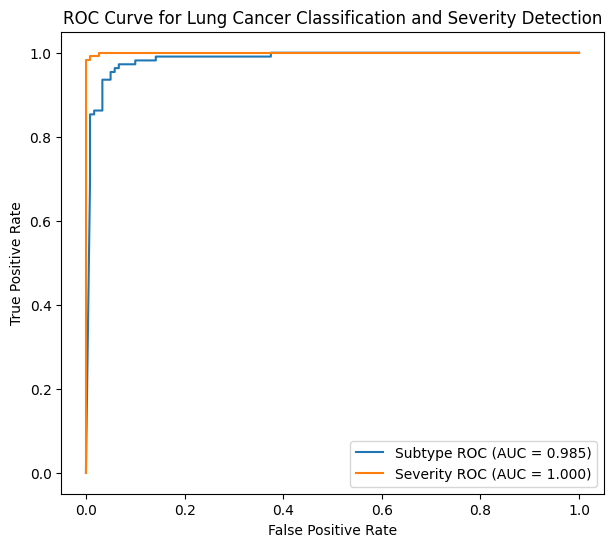

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
sub_prob , sev_prob = model.predict(X_test)
sub_pred = (sub_prob > 0.5).astype(int)
sev_pred = (sev_prob > 0.5).astype(int)

fpr_sub, tpr_sub, _ = roc_curve(y_test, sub_prob)
auc_sub = roc_auc_score(y_test, sub_prob)

fpr_sev, tpr_sev, _ = roc_curve(sev_test, sev_prob)
auc_sev = roc_auc_score(sev_test, sev_prob)

plt.figure(figsize=(7,6))
plt.plot(fpr_sub, tpr_sub, label=f'Subtype ROC (AUC = {auc_sub:.3f})')
plt.plot(fpr_sev, tpr_sev, label=f'Severity ROC (AUC = {auc_sev:.3f})')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Lung Cancer Classification and Severity Detection")
plt.legend()
plt.show()

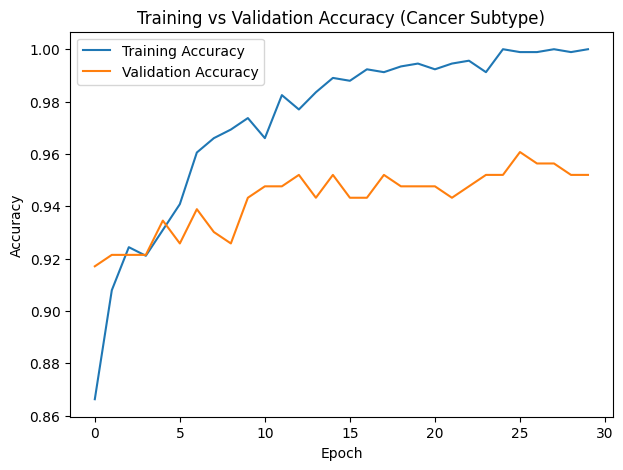

In [10]:
plt.figure(figsize=(7,5))
plt.plot(history.history['subtype_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_subtype_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy (Cancer Subtype)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

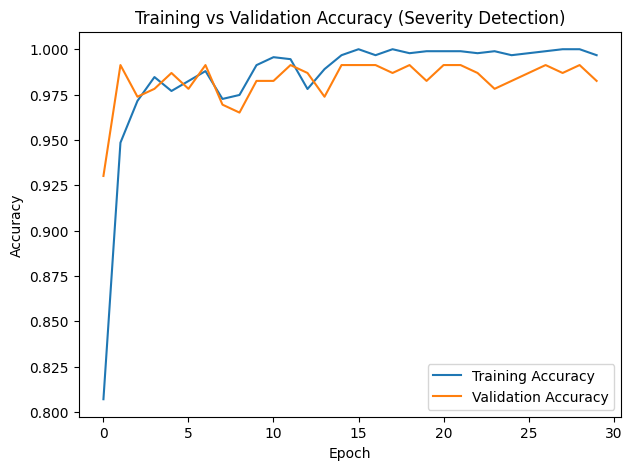

In [11]:
plt.figure(figsize=(7,5))

plt.plot(history.history['severity_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_severity_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy (Severity Detection)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.show()